<a href="https://colab.research.google.com/github/AnibalSJ/GCI_DataScience_AI_Matsuo_Lab/blob/main/lec12_time_series_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Data and Modeling


**Chapter Introduction**

The goal for this chapter is to **be able to predict time series data**. In the previous chapter, we learned an overview of time series data and feature engineering. In this chapter, we will learn about how to build make predictions on time series data. It may be challenging to cover everything within the lecture time, so let's grasp the outline.

Goal: To understand different models for time series data prediction.

- **[2.1 Time Series Data and Modeling](#6.1-教師なし学習)**
    - [2.1.1 What does it mean to "Predict" Time Series Data](#6.1.1-教師なしモデルの種類)
    - [2.1.2 Methods for Predicting Time Series Data](#6.1.2-この章で使うライブラリのインポート)
- **[2.2 Observing Time Series Data](#6.2-クラスタリング)**
    - [2.2.1 Importance of Exploratory Data Analysis (EDA)](#6.2.1-k-means法)
    - [2.2.2 Time Series Data Plotting](#6.2.2-k-means法でクラスタリングする)
    - [2.2.3 STL Decomposition](#6.2.3-金融マーケティングデータをクラスタリングする)   
- **[2.3 Qualitative Understanding of ARMA Models](#6.3-主成分分析)**
    - [2.3.1 Qualitative Understanding of AR Models](#6.3.1-主成分分析を試す)
    - [2.3.2 Qualitative Understanding of MA Models](#6.3.2-主成分分析の実例)
    - [2.3.3 Qualitative Understanding of ARMA model](#6.3.2-主成分分析の実例)
- **[2.4 Predicting Stationary Time Series with ARMA Processes](#6.4-マーケットバスケット分析とアソシエーションルール)**
    - [2.4.1 Autocorrelation](#6.4.1-マーケットバスケット分析とは)
    - [2.4.2 Stationarity](#6.4.2-マーケットバスケット分析のためのサンプルデータを読み込む)
    - [2.4.3 Determining the Order of ARMA Models](#6.4.3-アソシエーションルール)
    - [2.4.4 Forecasting with ARMA Models](#6.4.3-アソシエーションルール)
- **[2.5 Non-stationary Time Series Modeling with ARIMA Process](#6.5-総合問題)**
- **[2.6 Advanced Models](#6.5-総合問題)**
    - [2.6.1 Evolution of the ARIMA Model](#■-総合問題6-1-アソシエーションルール)
    - [2.6.2 Machine Learning Approach to Time Series Techniques](#■-総合問題6-1-アソシエーションルール)

 ## 2.1.1 What Does it Mean to "Predict" Time Series Data
Keywords: Different types of predictions

Just like with tabular data we have been analyzing, there is a need to predict time series data. However, the approach and methods for predicting time series data using machine learning models are slightly different from those used for tabular data.

There are various types of predictions of time series data. For example:

- **Stock price data** (numeric values changing over time)
    - Predicting future stock prices
- **Periodic medical imaging data** (images changing over time)
    - Predicting whether a person's stomach is abnormal based on endoscopic images of 3,000 people over one month (time series classification)
- **Audio data from a factory floor** (audio changing over time)
    - Predicting whether audio at a given point is normal or faulty (anomaly detection)
- **Posts from social media** (language changing over time)
    - Predicting trending topics

As you can see, the range of predictions in time series data is very broad. In this lecture, however, we will focus on future prediction for **univariate time series data**.

Up to this point, we have worked with tabular data, where we used explanatory variables (inputs) to predict objective variables (targets). That is, we created a model that takes explanatory variables as input and outputs predicted values for the target variable. By feeding new explanatory variables into the model, we obtained predictions for new records.

In contrast, when predicting the future of univariate time series data, we take past data up to the present and use it to predict future values. Specifically, we create a model that takes $n$ time series values immediately preceding the target time as input and outputs the predicted value at the target time.

In other words, we use past observations to predict values at future time points that have not yet been observed.

Keeping this difference in mind, let's continue learning about predictions in time series data.

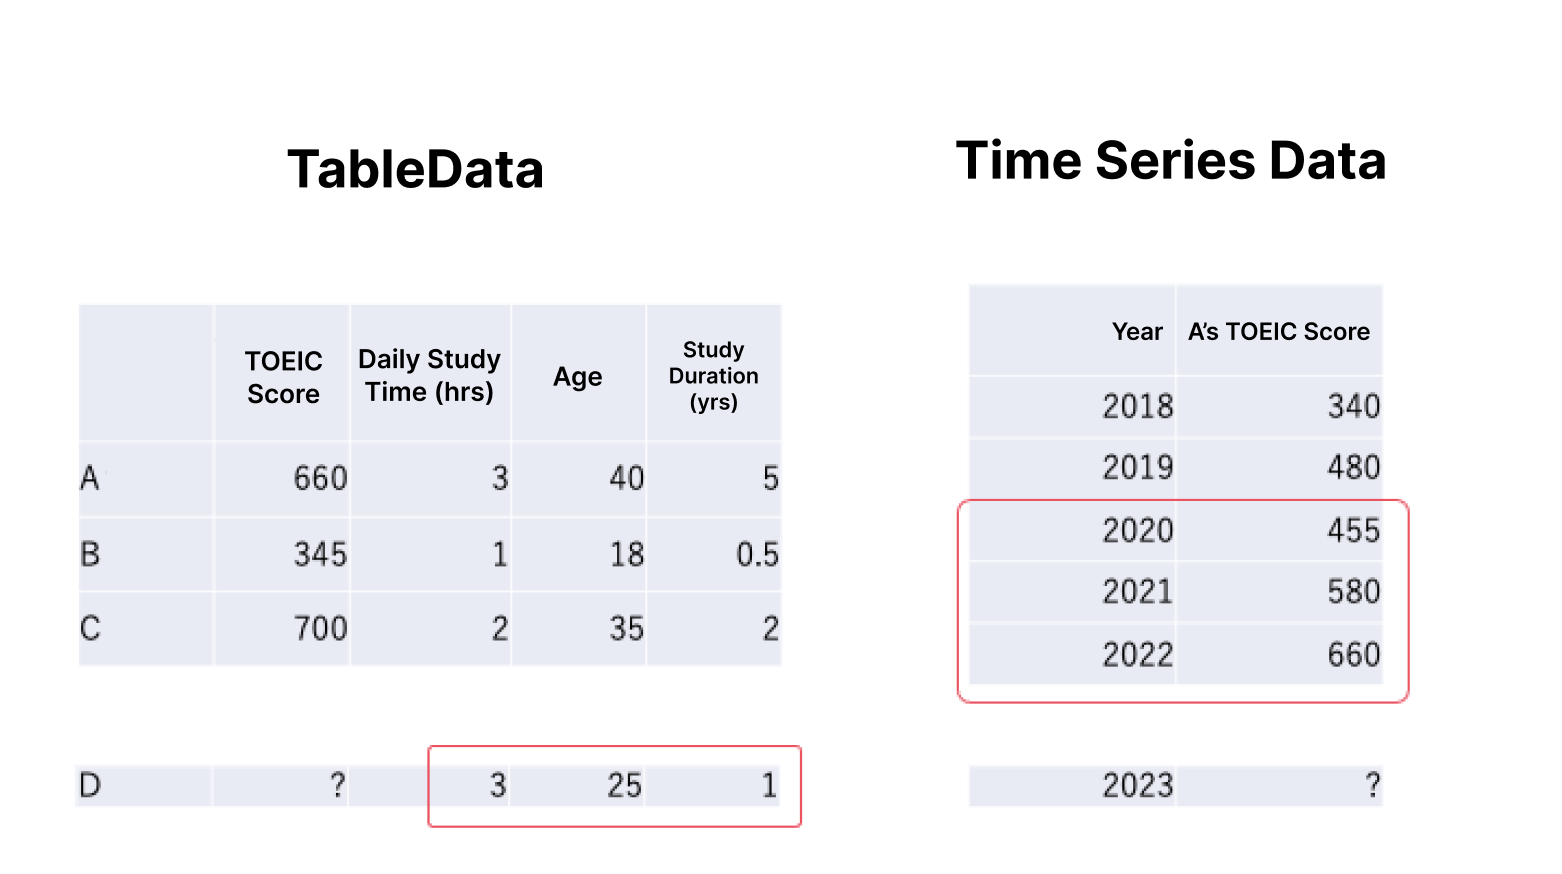

### 2.1.2 Methods for Predicting Time Series Data
Keywords: Statistical Approaches, Machine Learning Approaches

From now on, when we refer to "forecasting univariate time series data" we will simply say "predicting time series data".

There are various methods for predicting time series data, which can be mainly classified into two approaches: the "statistical approach" and the "machine learning approach".

In statistical approaches, predictions are made based on the assumption that time series data has specific statistical properties. Since the model parameters and their relationship with the data are relatively interpretable, it is easier to understand how the predictions are made. However, if the assumption of statistical properties does not hold, prediction performance may decrease.

In machine learning approaches, there is no need to assume statistical properties in the data. They can capture nonlinear relationships and complex patterns while making predictions. However, the prediction process becomes more complex, making it difficult to understand how predictions are made. With more data for training, though, we can generally expect better prediction accuracy.

Let's look at the different methods for each approaches.

- Statistical Approaches
  - ARIMA (autoregressive integrated moving average) models
  - SSM (state space model) models

- Machine Learning Approaches
  - Non-time-series methods
    - Random Forest, Support Vector Machine, etc.
  - Time series methods
    - RNN (Recurrent Neural Network), Transformer, etc.

In this lecture, we will focus on the most basic type: ARIMA models. Using these, we will learn how to predict time series data.

## 2.2 Observing Time Series Data
Goal: To be able to visualize time series data.

### 2.2.1 Importance of Exploratory Data Analysis (EDA)
Keywords: Seasonal Variations, Trends, Detecting anomalies and Outliers

Let's start by conducting Exploratory Data Analysis (EDA) on time series data.

Through the lectures so far, you may have realized the importance of EDA in tabular data. Similarly, EDA is crucial in time series data as well. There are many reasons to perform EDA on time series data, but here are two main reasons:

1. Clear understanding of **seasonal variations** and **trends**:
    - By plotting the data instead of just looking at a list of numbers, and by conducting methods such as Seasonal-Trend decomposition using Loess (STL), we can gain insights and clearly understand the characteristics of time series data.

2. Easy detection of **anomalies** and **outliers**:
    - Due to the presence of seasonality in time series data, it is challenging to identify anomalies and outliers at a glance. By decomposing the seasonality and trend, we can also detect anomalies and outliers.

Now, let's proceed with EDA.

### 2.2.2 Time Series Data Plotting
Keywords: Plot, Periodicity

We will be working with a dataset on the number of sunspots observed on the sun every year from 1702 to 2008.

First, let's execute the following cell to obtain the data we will be working with.

In [ ]:
import statsmodels.api as sm
import pandas as pd

sunspot_dataset = sm.datasets.sunspots.load_pandas().data

# Remove the first 2 data points for the purpose of the lecture
sunspot_dataset = sunspot_dataset.iloc[2:]

# Organize the data format
sunspot_dataset.index = pd.to_datetime(sunspot_dataset["YEAR"].astype(int), format='%Y')
sunspot_dataset = sunspot_dataset["SUNACTIVITY"]

Let's run the following cell to visualize the data.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Adjust the size of the plot for better visibility
plt.figure(figsize=(10, 5))
sunspot_dataset.plot()

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

From this plot, we can see that the number of sunspots varies significantly from year to year. We can also observe a recurring pattern of increase and decrease.  

The solar sunspot cycle said to be around 11 years on average.  
In fact, looking at the period from 1720 to 1820 over 100 years, we can see 9 peaks (points where the sunspot numbers are locally high). As $11\times9=99$, we can see that the this is a consistent result.

### 2.2.3 Autocorrelation
Keywords: Autocorrelation

<!-- In statistical approaches to time series modeling, including ARMA models, it is assumed that **future values are determined based on past values of the data**.  -->
As mentioned at the beginning of the lecture, in time series data **future values are thought to depend on past values**. In other words, past values correlate with future values.
How can we examine this correlation between past values correlate with future values?
<!-- So, let's check if the time series data we are dealing with indeed has correlations with past values. -->

The answer is simple -- you just have to calculate the **correlation coefficient** between a past & future value.
<!-- For this confirmation, we will use the -->
<!-- This correlation coefficient has its own name,  **autocorrelation coefficient**.  -->
<!-- as a measure of correlation with past data. -->

The **autocorrelation coefficient** is calculated as the correlation between the current data and data from $k$ periods ago (**lag** $k$). The formula to calculate the autocorrelation coefficient at lag $k$ can be expressed as follows:

\begin{aligned}  
\rho_k = \frac{\sum_{t=k+1}^{n} (X_{t}-\bar{X})(X_{t-k}-\bar{X})}{\sum_{t=1}^{n} (X_{t}-\bar{X})^2}
\end{aligned}

Here,

- $\rho_k$: Autocorrelation coefficient at lag $k$
- $X_t$: Observed value of time series data $X$ at time $t$
- $\hat{X}$: Mean value of time series data $X$

The autocorrelation coefficient $\rho_k$ takes values from -1 to 1, indicating a strong positive correlation as it approaches 1, a strong negative correlation as it approaches -1, and little to no correlation around 0. In other words, by calculating the autocorrelation coefficient, it becomes possible to understand to what extent past data influences current data.

Let's confirm the autocorrelation coefficients and draw a graph by using the `plot_acf()` function from the `statsmodels` library.

In [ ]:
# Import the plot_acf function to calculate and plot autocorrelation
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 7))
# Plot autocorrelation. By specifying lags=11, autocorrelation for 11 years (1 cycle) is calculated
plot_acf(sunspot_dataset, lags=11, ax=ax)
plt.xlabel('Lag')
plt.show()

This graph shows the data of autocorrelation coefficients of the sunspot data at different lags.

The horizontal axis indicates the lag (the shift in time). At lag 0, the correlation is with itself, so the autocorrelation is always 1.

The blue shaded region represents the **confidence interval**: if the bars fall within this band, we can say there is no significant autocorrelation at that lag. Bars extending outside the band indicate the presence of significant autocorrelation.

In this case, the pattern shows a damped oscillation, where correlations weaken as the lag increases but remain significant at certain intervals. This indicates that the series exhibits strong autocorrelation over multiple years.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
# This time, set lags = 50
plot_acf(sunspot_dataset, lags=50, ax=ax)
plt.xlabel('Lag')
plt.show()

Here, the correlogram shows a wavy pattern. And if you look carefully, the correlation coefficients get high and low every 10 or 11 years. And the first two peak values mark out of the confidence interval. All correlaion coefficients are within the confidence interval after about lag=28, but the wavy pattern continues. These findings indicate that there exist positive and negative correlations in your data in a 10- or 11-year period. In this way, a correlogram can help you find periodic patterns.

**Autocorrelation of an independent sequence**: Here we have seen that autocorrelation quantifies how past correlates with future. What does the autocorrelation look like if the sequence is completely independent each time, e.g., throwing a dice every 1 second for 5000 times? Obviously, the present roll does **NOT** correlate with future or past rolls.

In [ ]:
import numpy as np
dice_data = np.random.randint(1,7,5000)

fig, ax = plt.subplots(figsize=(10, 7))
plot_acf(dice_data, ax=ax)
plt.xlabel('Lag')
plt.show()

As you may have imagined, the correlogram hits almost zero whenever lag >=1. This indicates the trials are independent, and maybe you have to consider if you can apply time series models, which usually assumes autocorrelative nature in the data.

### 2.2.4 STL Decomposition
Keywords: STL Decomposition

So far, we have plotted time series data and checked its basic properties. However, when looking at time series, it is often difficult to visually distinguish long-term upward or downward trends, short-term fluctuations, or random noise. For example, in the case of sunspot counts, simply plotting the data does not clearly reveal whether there is a long-term increasing/decreasing trend or whether it just oscillates periodically.

To conduct a more detailed EDA of the time-series data, let's perform **STL decomposition**.

The **STL decomposition (Seasonal and Trend decomposition using Loess)** is a method for decomposing time series data into **trend**, **seasonal**, and **residual** components.  
At each time point $t$, the data $y_t$ can be expressed as:

```
y_t = T_t + S_t + R_T
```
where
- $T_t$: **Trend component** -- represents the long-term direction or gradual changes in the data
- $S_t$: **Seasonal component** — captures repeating cyclical patterns over a fixed period (e.g. daily, monthly, yearly cycles).
- $R_t$: **Residual component** — what remains after removing trend and seasonality; this includes random noise and unpredictable variations.

By decomposing and plotting in this manner, we can visualize the "overall direction of the data" (trend) and "periodic fluctuations" (seasonality) more clearly.  

STL decomposition is implemented in `statsmodels` library, inside `statsmodels.tsa.seasonal` module. Some key parameters are:
- `period`: the length of the seasonal cycle (must be set manually)
- `seasonal`: smoothing window size for the seasonal component
- `trend`: smoothing window size for the trend component
- `robust`: whether to use robust fitting (helps handle outliers)
We first instantiate it and then call `fit()` method. By doing so, it returns a result object with attributes such as, `trend`, `seasonal`, `resid`.

Let's execute the following cell and perform the STL decomposition.

In [ ]:
from statsmodels.tsa.seasonal import STL

# STL decomposition
stl = STL(sunspot_dataset, period=11)
res = stl.fit()

# Plot each component
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

sunspot_dataset.plot(ax=axes[0])
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_title('Original Data')

res.trend.plot(ax=axes[1])
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_title('Trend')

res.seasonal.plot(ax=axes[2])
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_title('Seasonal')

res.resid.plot(ax=axes[3])
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

We will now examine the results of the STL decomposition.

By looking at the Trend component, we can confirm the long-term trend of the data. The trend appears to fluctuate irregularly, but it can be seen to have a gradual increasing trend during this period.

Examining the Seasonal component allows us to confirm the seasonal nature of the data. After performing the STL decomposition, the presence of seasonality becomes more evident.

The Residual component represents prediction errors or noise, appearing in an irregular shape.

Through STL decomposition, we can see that it has become easier to grasp the trend of the data.

## 2.3 Statistical Models for Stationary Time Series Data

Goal: To conceptually understand the forecasting method for stationary time series data.

Since we have gone through the basics of exploratory data analysis and gained a deeper understanding of the data, let's move on to our main topic of prediction.

As mentioned earlier, there are many methods to forecast time series data. Among them, we will use the statistical approach of **ARMA** and **ARIMA** models.

These statistical approaches are relatively easy to interpret conceptually and are well-suited as introductory models for learning time series forecasting.

ARMA models can be seen as an extension of **AR** and **MA** models. ARIMA models are an advanced version of ARMA models. Let's begin by studying AR and MA individually before moving on to ARMA.

### 2.3.1 AR Models
Keywords: AR model, Past Observed Values

In an **Autoregressive (AR) model**, future data is predicted by summing up a constant multiple of the past data values.

Specifically, an AR model is represented by the following equation:

\begin{aligned}
X_t &= c + \phi_1 X_{t-1} + \phi_2X_{t-2} + ... +\phi_pX_{t-p} + \varepsilon_t \\
    &= c + \sum^p_{i=1}\phi_iX_{t-i} + \varepsilon_t
\end{aligned}

Here,

- $X_t$: Observation value of time series data X at time t<br>
- $\phi_i$: Coefficient of time series data X at time t - i<br>
- $\varepsilon_t$: Error term at time t<br>
- $p$: Total number (order) of past time series data X used for prediction
- $c$: Constant term

By effectively summing past data, we predict the data at the next time point.

For example, in the case of the sunsupot data, $\phi_i$ represents how the number of sunspots from $i$ years ago influece the current number. Positive coefficients mean past increases carry forward, negative ones mean the opposite. When $\phi$ is close to 0, it can be interpreted as having little to no impact.

### 2.3.2 MA Models
Keywords: MA model, past error terms

In the **Moving Average (MA) model**, future data is predicted by summing up a constant multiple of past errors (the difference between predicted value and actual value) of the data to be predicted.

Specifically, the MA model is represented by the following equation:

\begin{aligned}
X_t &= c + \varepsilon_t + \theta_1\varepsilon_{t - 1} + \theta_2\varepsilon_{t - 2} + ... + \theta_q\varepsilon_{t - q}\\
&= c + \varepsilon_t + \sum^q_{i=1}\theta_i\varepsilon_{t - i}
\end{aligned}

Here,  
- $X_t$: Observed value of time series data $X$ at time $t$  
- $\theta_i$: Coefficient of error term $\varepsilon$ at time $t-i$
- $\varepsilon_t$: Error term at time $t$  
- $q$: Total number (order) of past error terms used for prediction  
- $c$: Constant term

Although expressed in a formula similar to an AR model, an MA model predicts future values using **past error terms**.  

It may seem difficult to grasp at first, but if we perceive the error term as "over/underestimation from the predicted value", we can understand it qualitatively.  

Let me explain using the example of stock prices.  
Let's say we predicted the stock price for a certain day to be ¥10,000. However, the actual stock price turned out to be ¥11,000. In this case, the error is +¥1,000, indicating that it was "overestimated" compared to the prediction. One might think, "Let's predict slightly higher for the next day."

In this way, past prediction errors can be useful in predicting future values.

**Note**: Despite its terminology, the mean (≒average) of the MA (=moving average) model does **NOT** change! This is validated easily as follows:
\begin{equation*}
\textrm{E}[X_t] = \textrm{E}[ c + \varepsilon_t + \theta_1\varepsilon_{t - 1} + \theta_2\varepsilon_{t - 2} + ... + \theta_q\varepsilon_{t - q}] = c = \textrm{Const.},
\end{equation*}
where $\text{E}$ is the expectation operator. This indicates that the mean doesn't depend on time index $t$!

### 2.3.3 ARMA model
Keywords: AR Model, MA Model, ARMA Model

In an **ARMA model (AutoRegressive Moving Average model)**, both past values of the data and past error terms are utilized in making predictions. Specifically, future data points are predicted by adding a constant multiple of past data points to a constant multiple of past error terms.

The ARMA model is represented by the following equation:

\begin{aligned}
X_t &= c + \phi_1 X_{t-1} + \phi_2X_{t-2} + ... +\phi_pX_{t-p}  + \varepsilon_t + \theta_1\varepsilon_{t - 1} + \theta_2\varepsilon_{t - 2} + ... + \theta_q\varepsilon_{t - q}\\
    &= c + \varepsilon_t + \sum^p_{i=1}\phi_iX_{t-i} + \sum^q_{i=1}\theta_i\varepsilon_{t - i}
\end{aligned}

Here,  
- $X_t$: Observed value of time series data $X$ at time $t$  
- $\phi_i$: Coefficient of the time series data at time $t - i$  
- $\theta_i$: Coefficient of the error term $\varepsilon$ at time $t - i$
- $\varepsilon_t$: Error term at time $t$
- $p$: Total number (order) of past observations of time series data $X$ used for prediction   
- $q$: Total number (order) of past error terms used for prediction  
- $c$: Constant term

## 2.4 Predicting Stationary Time Series with ARMA Processes
Goal: To be able to predict stationary time series data.

### 2.4.1 Stationarity
Keywords: ADF Test, Hypothesis Testing

In ARMA models, if there is no **stationarity** in time series data, it could be difficult to predict the data effectively. **Stationarity** refers to the property where time series data transitions stably over time. Specifically, it means that the expected value of the time series data at each time point is constant, and the autocorrelation depends only on the time lag (more precisely, this property is called **weak stationarity**). This essentially implies that if time series data is stationary, the properties of the data remain constant regardless of time. It is expected that future data can be predicted based on past data characteristics.

On the other hand, data without stationarity is called **non-stationary** data. Non-stationary data has changing properties as time progresses.
When the properties of time series data change as time progresses, creating a learning model using past data may lead to unreliable predictions for future data.

Let's now check if there is stationarity in the sunspot data.  
To determine the presence of stationarity, we can use something called the [Augmented Dickey-Fuller (ADF)](https://en.wikipedia.org/wiki/Augmented_Dickey%E2%80%93Fuller_test) test.   
In Python, we can use the `adfuller` module from `statsmodels` library.

In [ ]:
# Importing a module that allows for the Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller

# Executing the Augmented Dickey-Fuller test
result = adfuller(sunspot_dataset)

# Displaying the results
# print('Test Statistic\t: %f' % result[0])
print('p-value\t: %f' % result[1])
# print('Critical Values\t:')
# for key, value in result[4].items():
#     print('\t%s\t: %.3f' % (key, value))

# Evaluating the p-value
if result[1] < 0.05:
    print("The time series data is considered stationary.")
else:
    print("The time series data is not considered stationary.")

The ADF test is a statistical hypothesis test designed to evaluate whether a time series contains a unit root. The **null hypothesis is that the series has a unit root**, which means it is non-stationary. The alternative hypothesis is that the series does not have a unit root and is therefore stationary.

The p-value indicates the probability of observing the data if the null hypothesis were true. If the p-value is small—commonly less than 0.05—we reject the null hypothesis and conclude that the data is stationary. If the p-value is larger, we do not have sufficient evidence to reject the null, and we must consider the data as potentially non-stationary. In the example above, the ADF test on the sunspot dataset produces a p-value of 0.048, which falls just below the 0.05 threshold. This means that under the assumption of non-stationarity, the likelihood of obtaining data that looks as stationary as what we observed is only about 4.8%. Because this probability is small, we reject the null hypothesis and conclude that the sunspot data can reasonably be considered stationary.

This conclusion gives us confidence that the ARMA model, which requires stationarity as a foundational assumption, can be safely applied to this dataset for forecasting.

### 2.4.2 Determining the Hyperparameters of ARMA Models
Keyword: AIC

First, let's summarize what we have learned about the ARMA model.


-   Prediction Method
    -   Predicting future values based on past observed values and past error terms over a specific period
-   Required Statistical Properties
    -   Stationarity (data characteristics remain constant over time)
        -   Confirm using the ADF test
    -   Autocorrelation (past observed values influencing future observed values)
        -   Verify by plotting autocorrelation coefficients

And the ARMA model was represented by the following formula.

\begin{aligned}
X_t &= c + \phi_1 X_{t-1} + \phi_2X_{t-2} + ... +\phi_pX_{t-p}  + \varepsilon_t + \theta_1\varepsilon_{t - 1} + \theta_2\varepsilon_{t - 2} + ... + \theta_q\varepsilon_{t - q}\\
    &= c + \varepsilon_t + \sum^p_{i=1}\phi_iX_{t-i} + \sum^q_{i=1}\theta_i\varepsilon_{t - i}
\end{aligned}

Now that you've understood the overview and the necessary statistical properties of the ARMA model, we will proceed with making predictions using the ARMA model.

In the ARMA model, determining "how many past observations and error terms to use in predicting future values" or in other words, "setting the values of p and q (orders)" is crucial.
Having higher orders is not always better.
As the orders increase, the model becomes more complex and may lead to overfitting.

Here, we will estimate the appropriate orders for the observations and error terms to be used in prediction using **AIC (Akaike Information Criterion)**.

AIC is represented by the following formula.

$$\text{AIC} = 2k - 2\ln(L)$$

Here,
- $k$: number of parameters in the model (complexity)<br>
- $L$: maximum likelihood (goodness of fit of the model to the data)

AIC serves as a metric to evaluate the trade-off between the complexity of the model and its goodness of fit to the data. Therefore, by selecting a model with a lower AIC value, we can choose the model that strikes the best balance between the goodness of fit to the data (likelihood) and the simplicity of the model (number of parameters).

Thus, we select the combination of periods with the lowest AIC values and create an appropriate predictive model.

In this sunspot data, which has an 11-year cycle, we will conduct a grid search with the maximum degrees of the past observed values and error terms both set to 11. We will then select the combination with the lowest AIC.

In [ ]:
# Split dataset: use oldest 95% for training and latest 5% for testing
len_test = int(0.05 * len(sunspot_dataset))
train = sunspot_dataset[:len(sunspot_dataset) - len_test]
test = sunspot_dataset[len(sunspot_dataset) - len_test:]

In [ ]:
# Execution of this cell takes time (5-6 minutes)
import statsmodels.api as sm
import numpy as np

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

# First, set the range of model parameters
max_ar = 11  # Maximum AR order
max_ma = 11  # Maximum MA order

# Initialize the minimum AIC to infinity
best_aic = np.inf
best_order = None

# Fit the model for all combinations of parameters
for p in range(max_ar + 1):
    for q in range(max_ma + 1):
        try:
            # Create the model
            # p is the number of past observed values used for prediction, q is the number of past error terms used for prediction
            # Although it is written as ARIMA, when the middle number is 0 as in (p, 0, q), it becomes an ARMA model
            tmp_mdl = ARIMA(train, order=(p, 0, q), freq="AS")
            result = tmp_mdl.fit()
            tmp_aic = result.aic
            # If AIC is small, update the model and parameters
            if tmp_aic < best_aic:
                best_aic = tmp_aic
                best_order = (p, q)
        except:
            print("error")
            continue

print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))

In this forecasting model of sunspot data using the ARMA model, we can see that using past observed values from 8 years and error terms from 6 years minimizes the AIC to predict future values.

### 2.4.3 Forecasting with ARMA Models
Keywords: Forecasting Time Series Data

Now let's proceed to actually making predictions using the ARMA model and plotting the results.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.grid(True, linestyle='--', alpha=0.5)

# Use historical forecast values for 8 years and error terms for 6 years (based on grid search using AIC)
arma_model = ARIMA(train, order=(8, 0, 6), freq="AS")
result = arma_model.fit()
forecast = result.forecast(len_test)

# Display the original data with a blue (default) line
ax.plot(sunspot_dataset, ls="-")
# Display the forecasted results with a red line
ax.plot(forecast, ls="-", color="r", label="predicted")


# Calculate the Mean Squared Error between predicted data and actual data
mse = mean_squared_error(test, forecast)

print("Mean Squared Error:", mse)

We were able to predict unknown test data quite accurately. As we have just seen, ARMA models is useful in predicting future values of stationary time series data.

## 2.5 Non-stationary Time Series Modeling with ARIMA Process

Goal: To be able to forecast time series data even when the data is non-stationary.

As mentioned earlier, in the ARMA model, we assumed stationarity (the property of data being constant over time) of the data. However, in reality, there are many non-stationary time series data. It is inconvenient not to be able to predict those.

The **ARIMA model (Autoregressive Integrated Moving Average model)** is an extension of the ARMA model that can be applied to non-stationary datasets.

Let's learn about the ARIMA model to be able to build prediction models for various time series data.

Here, we will be using time series data recording the concentration of carbon dioxide (CO2) in the atmosphere on a weekly basis.  
More specifically, this dataset consists of the atmospheric CO2 concentrations (in parts per million, ppm) measured at the Mauna Loa Observatory in Hawaii, United States, from 1958 to 2001.  

Due to the large amount of data, we will focus on the data from 1981 to 2001 for this analysis.  
Moreover, we will take averages for each month and treat the data as monthly atmospheric CO2 concentration.

First, let's load the dataset in the cell below.

In [ ]:
import statsmodels.datasets.co2 as co2
import pandas as pd

# Load CO2 data
co2_data = co2.load().data

# Retrieve data from 1981 onwards
co2_data = co2_data.iloc[1188:]

# Set 'date' column as datetime type and use it as index
co2_data.index = pd.to_datetime(co2_data.index)

# Convert to monthly data (get the last day of the month)
co2_data = co2_data.resample('M').mean()
print(co2_data)

In [ ]:
# Plot
import matplotlib.pyplot as plt
co2_data.plot()

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

Looking at this graph, it appears that there is a yearly cycle, and we can also see a trend of overall increasing data.

Let's also check with STL decomposition.

In [ ]:
from statsmodels.tsa.seasonal import STL

# STL decomposition
stl = STL(co2_data, period=11)
res = stl.fit()

# Plot each component
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

co2_data.plot(ax=axes[0])
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_title('Original Data')

res.trend.plot(ax=axes[1])
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_title('Trend')

res.seasonal.plot(ax=axes[2])
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_title('Seasonal')

res.resid.plot(ax=axes[3])
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

Indeed, we have observed an upward trend and periodicity. Let's conduct an ADF test to confirm if this data is stationary.

In [ ]:
# Import module that allows conducting ADF test
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(co2_data)

# Display the results
print('Statistical test statistic\t: %f' % result[0])
print('p-value\t: %f' % result[1])
print('Critical values\t:')
for key, value in result[4].items():
    print('\t%s\t: %.3f' % (key, value))

# Evaluate the p-value
if result[1] < 0.05:
    print("The time series data is considered stationary.")
else:
    print("The time series data is not considered stationary.")

Based on the results of the ADF test, it was found that the **CO2 concentration data is not stationary**.

In this case, creating a predictive model using an ARMA model as is may lead to inappropriate forecasting results.

One possible cause of a non-stationary data is the presence of a **trend**. A trend refers to the systematic tendency of data to change in a certain direction over time. In this dataset, we can observe an upward trend.

However, even in such non-stationary data, there are cases where the difference between adjacent data points (first-order differencing) becomes stationary. The first-order differencing data essentially represents the "amount of change from the previous time point" at each time point.

Taking the first-order difference from data with a trend can remove a constant trend, making the data properties constant regardless of time.

Let's now take a look at the data after taking the first difference.

In [ ]:
# Create data of the difference between adjacent time points
co2_data_diff = co2_data.diff().dropna()

# Adjust the size of the graph for better visibility
plt.figure(figsize=(10, 5))

# Display the plot
co2_data_diff.plot()

# Display the length
print(len(co2_data_diff))
# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

It no longer appears to be on an upward trend, the rising trend seems to have resolved. Let's also check with the STL decomposition.

In [ ]:
from statsmodels.tsa.seasonal import STL

# STL decomposition
stl = STL(co2_data_diff, period=11)
res = stl.fit()

# Plot each component
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

co2_data_diff.plot(ax=axes[0])
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_title('Original Data')

res.trend.plot(ax=axes[1])
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_title('Trend')

res.seasonal.plot(ax=axes[2])
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_title('Seasonal')

res.resid.plot(ax=axes[3])
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

As expected, we can see that the influence of the upward trend has been removed.

Next, let's conduct an ADF test on the differenced data to check for stationarity.

In [ ]:
# Import module for performing Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller Test
result = adfuller(co2_data_diff)

# Display the results
print('Statistical test statistic\t: %f' % result[0])
print('p-value\t: %f' % result[1])
print('Critical values\t:')
for key, value in result[4].items():
    print('\t%s\t: %.3f' % (key, value))

# Evaluate the p-value
if result[1] < 0.05:
    print("The time series data is considered stationary.")
else:
    print("The time series data is not considered stationary.")

This time, we found that data after taking a first difference is stationary.

If you cannot achieve stationarity even after taking the first difference, you may need to take a second difference (difference of differences) to achieve stationarity.

The ARIMA model is a model used for forecasting on data that can achieve stationarity by taking differences $n$ times.  
After taking differences, we use the same method as the ARMA model to make predictions.

Now, let's conduct AIC, select the appropriate order for past observed values and error terms, and make predictions.

In [ ]:
# Prepare training data and test data
len_test = 12
train = co2_data[:len(co2_data) -len_test]
test = co2_data[len(co2_data)-len_test:]

In [ ]:
# Running this cell will take time (5,6 minutes)
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

# First, set the range for model parameters
max_ar = 12  # Maximum order of AR
max_ma = 3  # Maximum order of MA

# Initialize the minimum AIC with infinity
best_aic = np.inf
best_order = None

# Fit the model for all combinations of parameters
for p in range(max_ar+1):
    for q in range(max_ma+1):
        try:
            # Create model
            # p: number of lag observations included in the model, q: the order of the moving average
            tmp_mdl = ARIMA(train, order=(p, 1, q))
            result = tmp_mdl.fit()
            tmp_aic = result.aic
            # Update the model and parameters if AIC is small
            if tmp_aic < best_aic:
                best_aic = tmp_aic
                best_order = (p, q)
        except: continue

print('aic: {:6.5f} | order: {}'.format(best_aic, best_order))

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.grid(True, linestyle='--', alpha=0.5)

# Perform prediction using ARMA model with p=12, q=2 based on the results obtained from grid search in terms of AIC
# The 1 in order=(12, 1, 2) represents first order differencing
arma_model = ARIMA(train, order=(12, 1, 2))
result = arma_model.fit()
forecast = result.forecast(len_test)

# Display the original data with a blue line (default)
ax.plot(co2_data, ls="-")
# Display the forecasted results with a red line
ax.plot(forecast, ls="-", color="r", label="predicted")

We can confirm that accurate predictions are being made.

## 2.6 Advanced Models

In this chapter, we have learned about the EDA and forecasting of univariate time series data. Particularly regarding forecasting, we have learned to predict future data using ARMA and ARIMA models. However, as mentioned at the beginning of this section, besides the univariate time series data we dealt with this time, there are various forms of time series data and various forecasting methods. In the end, we will provide an example of a roadmap for future learning as we cannot introduce them all.

### 2.6.1 Evolution of the ARIMA Model
Keywords: SARIMA, SARIMAX

The ARIMA model introduced earlier allows predictions even for non-stationary data. However, the predictive performance of the ARIMA model may be limited for data with seasonality (for example, sales data that increase during specific seasons throughout the year).  
With **Seasonal AutoRegressive Integrated Moving Average model (SARIMA)**, seasonal trends are taken into account, enabling higher prediction accuracy for data with seasonality.

In **SARIMAX (Seasonal Autoregressive Integrated Moving Average model with exogenous variables)**, we can use variables other than the one we want to predict to make forecasts.

These models are provided in Python libraries.

Since you have learned the ARIMA model, you should find the concepts of SARIMA and SARIMAX models relatively easy to understand.

I encourage you to master them.

### 2.6.2 Machine Learning Approach to Time Series Techniques
Keywords: Neural Network, RNN, LSTM

This chapter have focused on introducing predictive models with a statistical approach. However, machine learning approaches are equally important. With machine learning approaches, it is possible to make predictions while capturing non-linear relationships and complex patterns, leading to high prediction accuracy.

Although not covered in this lecture, deep learning methods (such as neural networks) are particularly effective and are an actively researched field.